In [3]:
from set_up.generic_business_case_runner import run_business_case

from EL_input_data import el_parameters
from OWF_input_data import owf_parameters

import ipynb.fs.defs.EL_working_file as el_module
import ipynb.fs.defs.OWF_working_file as owf_module

import EL_input_data as el_inputs
import OWF_input_data as owf_inputs

import set_up.generic_business_case_runner as runner

from analysis.sensitivity import run_oat_sensitivity,get_base_case_values,tornado_plot
from analysis.cum_equity_debt_figure import plot_cumulative_cashflows
from analysis.scenario_analysis import run_levelized_breakdown_scenarios, plot_scenario_breakdown

**Sensitivity analysis**

In [4]:
# Run the sensitivity analysis, this will give 4 KPI dfs
df_proj_npv_sa, df_eq_npv_sa, df_lco_sa, df_gap_sa = run_oat_sensitivity(owf_module, runner, owf_parameters)

# View all tables
print("--- 1) PROJECT NPV SENSITIVITY ---")
display(df_proj_npv_sa.style.format(precision=2))

print("\n--- 2) EQUITY NPV SENSITIVITY ---")
display(df_eq_npv_sa.style.format(precision=2))

print("\n--- 3) LEVELIZED COST SENSITIVITY ---")
display(df_lco_sa.style.format(precision=2))

print("\n--- 4) UNPROFITABLE GAP SENSITIVITY ---")
display(df_gap_sa.style.format(precision=2))

--- 1) PROJECT NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-803.08,-763.29
wacc,-742.56,-821.75
income_tax_rate,-785.63,-785.63
inflation,-801.46,-769.35
loan_interest_rate,-785.63,-785.63
loan_percentage,-785.63,-785.63
decommissioning_percentage,-785.63,-785.63
capex,-639.03,-932.23
opex_df,-755.32,-815.94



--- 2) EQUITY NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-671.46,-638.37
wacc,-656.93,-654.58
income_tax_rate,-656.45,-657.36
inflation,-670.76,-643.14
loan_interest_rate,-639.21,-676.12
loan_percentage,-708.63,-601.79
decommissioning_percentage,-656.91,-656.91
capex,-552.90,-763.26
opex_df,-629.73,-684.87



--- 3) LEVELIZED COST SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,79.50,75.80
wacc,72.93,82.78
income_tax_rate,77.75,77.78
inflation,77.45,78.11
loan_interest_rate,76.49,79.19
loan_percentage,76.04,79.76
decommissioning_percentage,77.77,77.77
capex,70.61,85.39
opex_df,76.82,78.74



--- 4) UNPROFITABLE GAP SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-44.81,-41.13
wacc,-38.29,-48.11
income_tax_rate,-43.10,-43.13
inflation,-43.60,-42.63
loan_interest_rate,-41.83,-44.53
loan_percentage,-41.38,-45.11
decommissioning_percentage,-43.11,-43.11
capex,-35.95,-50.74
opex_df,-42.16,-44.09


Tornado graphs

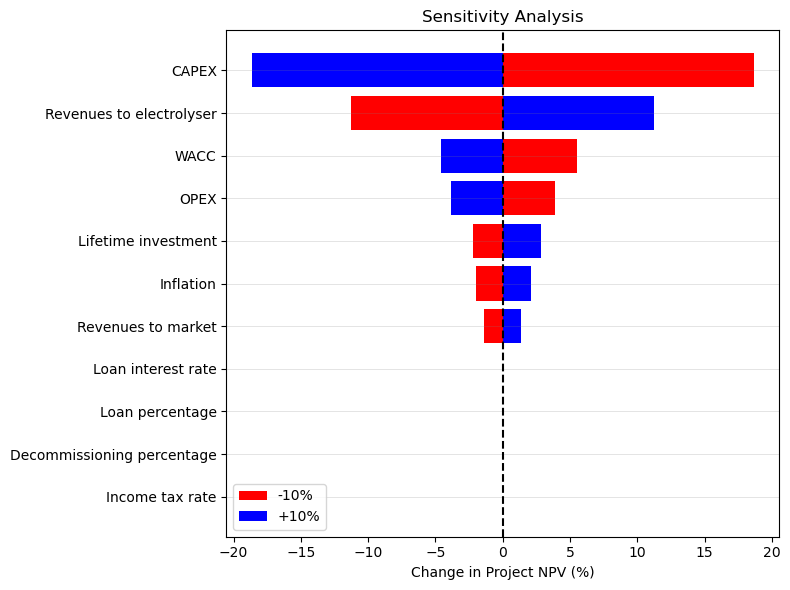

In [5]:
# First we get the base case values
owf_base_cases = get_base_case_values(owf_module, runner, owf_parameters)
el_base_cases = get_base_case_values(el_module, runner, el_parameters)

# Plot the Project NPV tornado graph 
tornado_plot(df_proj_npv_sa,owf_base_cases['Project NPV'],'Project NPV')

# Plot the Equity NPV tornado graph 
# tornado_plot(df_eq_npv_sa,el_base_cases['Equity NPV'], 'Equity NPV')

# Plot the Levelized Cost tornado graph
# tornado_plot(df_lco_sa, el_base_cases['Levelized Cost'], 'Levelized Cost')

# Plot the Unprofitable Gap tornado graph
# tornado_plot(df_gap_sa,el_base_cases['Unprofitable Gap'], 'Unprofitable Gap')

Cumulative equity and debt figure

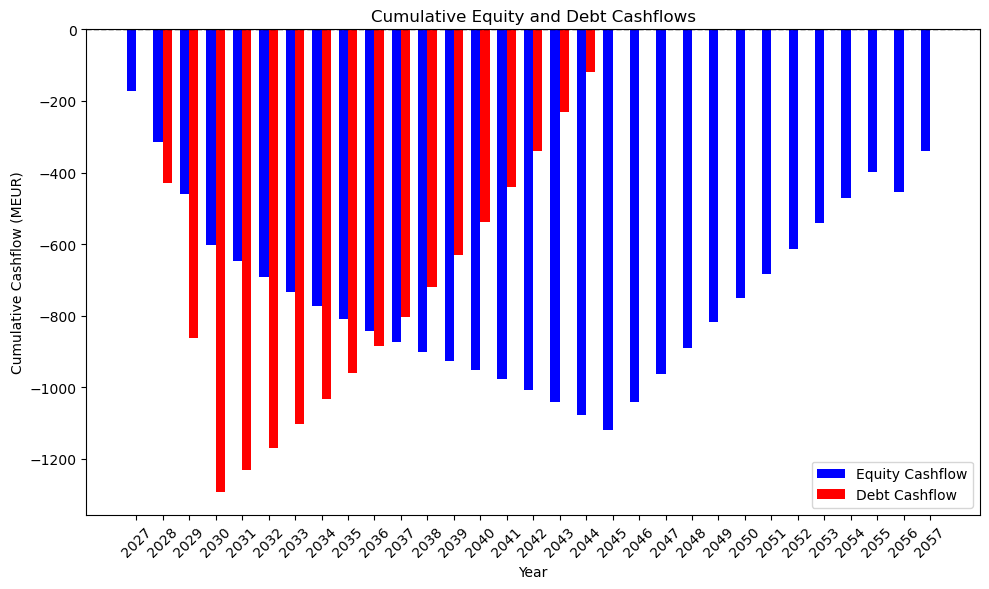

In [6]:
# Plot the graph
plot_cumulative_cashflows(owf_module, runner, owf_parameters)

**Pessimistic, most likely, optimistic scenarios**

In [7]:
# Get the df with levelized cost and revenues for all scenarios
df_analysis = run_levelized_breakdown_scenarios(runner, owf_module, owf_inputs, "owf_parameters")
display(df_analysis.style.format(precision=2))

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


levelized cost calculations,Cost (Pessimistic),Revenue (Pessimistic),Cost (Base),Revenue (Base),Cost (Optimistic),Revenue (Optimistic)
capex,79.35,0.00,51.12,0.00,33.44,0.00
opex,17.65,0.00,10.57,0.00,7.70,0.00
decommissioning,0.36,0.00,0.36,0.00,0.23,0.00
interest_costs,20.78,0.00,10.07,0.00,4.50,0.00
contingency,8.51,0.00,5.49,0.00,3.70,0.00
tax_expenses,0.00,0.00,0.16,0.00,4.84,0.00
revenues_ppa,0.00,25.54,0.00,30.85,0.00,37.25
revenues_market,0.00,2.97,0.00,3.80,0.00,4.74
profits,0.00,0.00,0.00,0.00,0.00,0.00
unprofitable_gap,0.00,98.15,0.00,43.11,0.00,12.42


Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


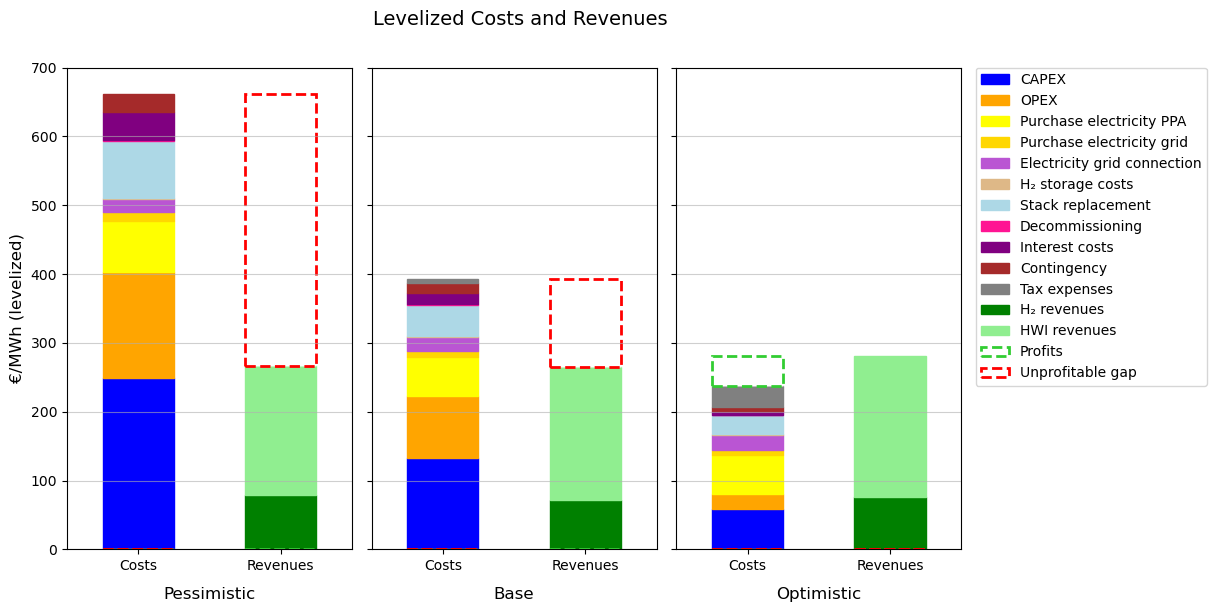

In [8]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, el_module, el_inputs, "el_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')


Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)


Active Scenario: optimistic (Index: 2)


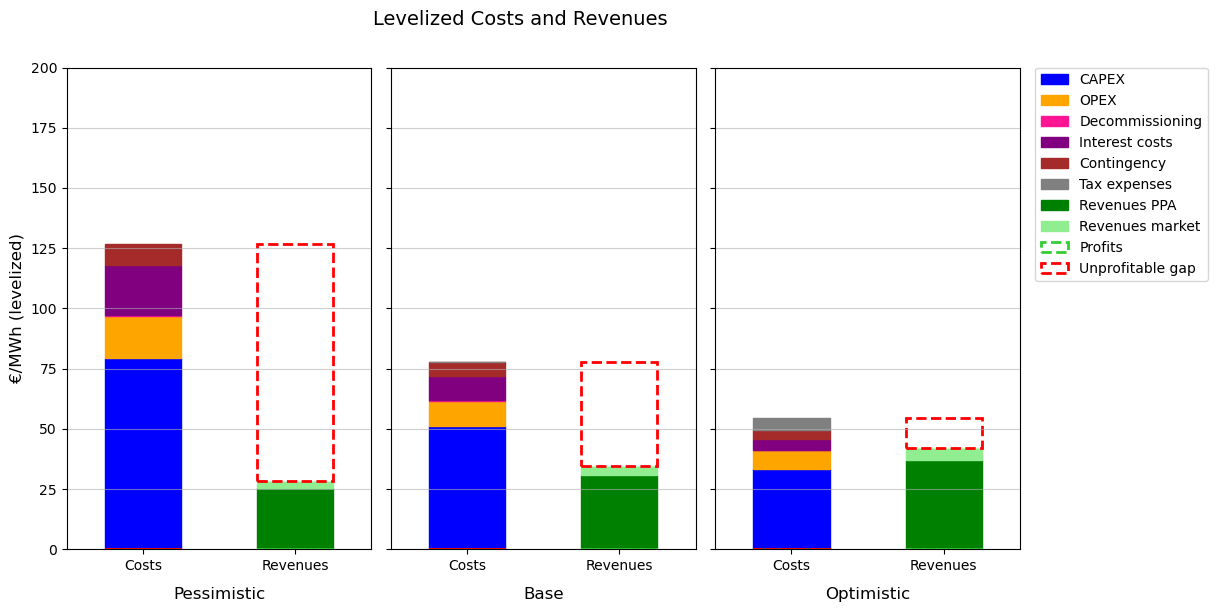

In [9]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, owf_module, owf_inputs, "owf_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')